In [37]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [38]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# FUNCTIONS =========================
# for nice plotting
def without_hue(plot, feature, yp=20):
    total = len(feature)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height() + yp
        ax.annotate(percentage, (x, y), size=10)
    plt.show()

def adjusted_prediction(model, text, priors, labels):
    # X = vectorizer.transform([text])
    # X = np.array([text]).reshape(1, -1) 
    X = [text]

    probs = model.predict_proba(X)[0]  # shape: (3,)

    adjusted = []
    for i, p in enumerate(probs):
        adj = p / ((0.5 + priors[i]) / 2)
        adjusted.append(adj)

    adjusted = np.array(adjusted)

    # normalize (VERY IMPORTANT)
    adjusted = adjusted / adjusted.sum()

    label_idx = np.argmax(adjusted)

    return labels[label_idx], adjusted

def get_topic(lda_model, vectorizer, text, sentiment_label=None):
    X = vectorizer.transform([text])
    if sentiment_label=="negative":
        lda_model = lda_neg
    else: lda_model = lda_pos
    
    topic_dist = lda_model.transform(X)
    topic_idx = topic_dist.argmax()

    return topic_idx, topic_dist

def sparse_to_array(X):
    return X.toarray()

# LOAD DATA =========================
def load_data():
    df = pd.read_csv("../data/df_final.csv")
    return df

df = load_data()
def load_model():
    model = joblib.load('../models/basic_model_lr.joblib')
    vectorizer = joblib.load('../models/vectorizer.joblib')
    lda_neg = joblib.load('../models/lda_neg.joblib')
    lda_pos = joblib.load('../models/lda_pos.joblib')

    return model, vectorizer, lda_neg, lda_pos

model, vectorizer, lda_neg, lda_pos = load_model()


In [39]:
labels = model.classes_.tolist()
priors = df["sentiment_label"].value_counts(normalize=True).reindex(labels).fillna(0).tolist()

In [44]:
model.steps[-1][1].predict_proba(["ddd"])

ValueError: Expected 2D array, got 1D array instead:
array=['ddd'].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [45]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('text', ...), ('to_dense', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'

In [29]:
user_input = "Eakk dude"

label, probs = adjusted_prediction(
                model, user_input, priors, labels
)

emoji_map = {
    "negative": "😡",
    "neutral": "😐",
    "positive": "😊"
}

In [37]:
model.predict_proba(["ddd"])

array([[0.04239496, 0.05448848, 0.90311656]])

In [33]:
model.predict_proba(["ddd"])
model.classes_.tolist()

['negative', 'neutral', 'positive']

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('text', ...), ('to_dense', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'

In [4]:

# --- Probability display ---
st.write("Adjusted Confidence:")

sorted_idx = np.argsort(probs)[::-1]
for i in sorted_idx:
    st.write(f"- {labels[i]}: {probs[i]:.2f}")

# --- Topic ---
topic_idx, topic_dist = get_topic(
    lda_neg, vectorizer, user_input, sentiment_label=label
)

# mapping if label == negative: from 012 to 120
if label == "negative":
    topic_idx = (topic_idx + 1) % 3

topic_labels = {
    0: "Product Expectation Match",
    1: "Product Quality",
    2: "Delivery & Packaging"
}

st.subheader("Topic Insight")
st.write(f"Most related topic: **{topic_labels.get(topic_idx, 'Unknown')}**")


2026-04-03 18:10:48.561 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 18:10:50.024 
  command:

    streamlit run c:\Users\ACER\OneDrive\Jobless\Projects\customer-review\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-03 18:10:50.028 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 18:10:50.032 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 18:10:50.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 18:10:50.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 18:10:50.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03

In [ ]:
user_input = "Eakk dude"

label, probs = adjusted_prediction(
                model, user_input, priors, labels
)

emoji_map = {
    "negative": "😡",
    "neutral": "😐",
    "positive": "😊"
}

,review_text,clean_text,review_date,clean_length,tokenized,sentiment_label,dominant_topic
0,barang bagus proses cepat,barang bagus proses cepat,2025-07-11,4,"['barang', 'bagus', 'proses', 'cepat']",positive,Accurate Orders
1,Bagus sesuai,bagus sesuai,2025-03-07,2,"['bagus', 'sesuai']",positive,Accurate Orders
2,Cepat kirimnya dalam sejam. Porsi medium cukup...,cepat kirimnya dalam sejam porsi medium cukup ...,2021-09-04,11,"['cepat', 'kirimnya', 'dalam', 'sejam', 'porsi...",positive,Fast Delivery & Packaging
3,"kaos kakinya nyaman dipake, rubber di bagian b...",kaos kakinya nyaman dipakai rubber di bagian b...,2024-07-15,12,"['kaos', 'kakinya', 'nyaman', 'dipakai', 'rubb...",positive,Good Product Quality
4,Pengiriman lama sekali padahal jarak begitu dekat,pengiriman lama sekali padahal jarak begitu dekat,2022-09-07,7,"['pengiriman', 'lama', 'sekali', 'padahal', 'j...",neutral,NaN


In [40]:
import matplotlib.dates as mdates

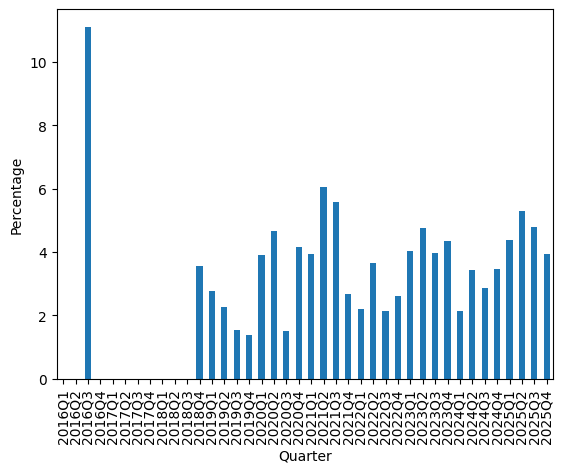

In [42]:
df["review_date"] = pd.to_datetime(df["review_date"])
df["quarter"] = df["review_date"].dt.to_period("Q")

negative_by_quarter = df[df["sentiment_label"] == "negative"].groupby("quarter").size()
# negative percentage
negative_by_quarter = negative_by_quarter / df.groupby("quarter").size() * 100

fig, ax = plt.subplots()
negative_by_quarter.plot(kind="bar", ax=ax)

# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter(''))

ax.set_xlabel("Quarter")
ax.set_ylabel("Percentage")
plt.show()


In [43]:
def without_hue(plot, feature, yp=20):
    total = len(feature)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height() + yp
        ax.annotate(percentage, (x, y), size = 10)
    plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_24340\966829285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="dominant_topic", data=neg_df, palette="muted")


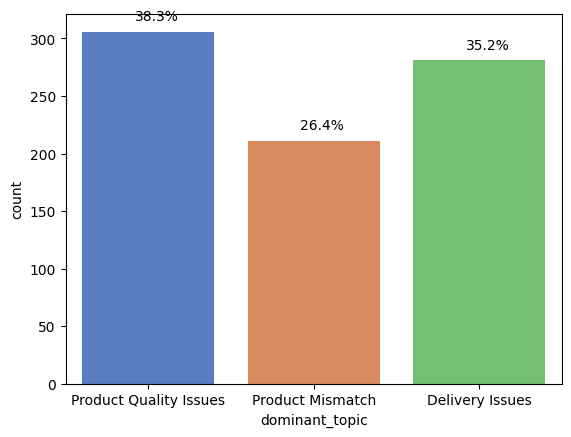

In [ ]:
fig, ax = plt.subplots()
neg_df = df[df["sentiment_label"] == "negative"]
sns.countplot(x="dominant_topic", data=neg_df, palette="muted")

without_hue(ax, neg_df["dominant_topic"], yp=10)

ax.set_xlabel("Topic")
ax.set_ylabel("Count")

plt.show()

In [51]:
def sparse_to_array(X):
    return X.toarray()

import joblib

def load_model():
    model_lr = joblib.load('../models/basic_model_lr.joblib')
    return model_lr

model = load_model()

In [55]:

labels = model.classes_.tolist()


df["sentiment_label"].value_counts(normalize=True).reindex(labels).fillna(0)

sentiment_label
negative    0.036958
neutral     0.037097
positive    0.925945
Name: proportion, dtype: float64